In [1]:
import sys
sys.path.insert(0, '../src')

import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

from config import load_config
from dataset_coco import COCOInstanceDataset
from models import UNetResNet50
from lightning_module import SegmentationModule

In [ ]:
config = load_config('../configs/config_coco_unet.json')

DATA_ROOT = config['data']['root_dir']
TRAIN_SPLIT = config['data']['split']
VAL_SPLIT = config['data']['val_split']
TEST_SPLIT = config['data']['test_split']
TARGET_SIZE = tuple(config['data']['target_size'])
BATCH_SIZE = config['data']['batch_size']
NUM_WORKERS = config['data']['num_workers']
MIN_AREA = config['data']['min_area']
MODE = config['data']['mode']
NUM_CLASSES = config['model']['num_classes']

MAX_EPOCHS = config['training']['max_epochs']
LEARNING_RATE = config['training']['learning_rate']

print(f"Model: UNet-ResNet50")
print(f"Classes: {NUM_CLASSES}")


Model: UNet-ResNet50
Task: Semantic Segmentation (Person + Vehicles)
Train split: train
Test split: test
Classes: 2
Batch size: 8
Mode: semantic


In [ ]:
train_dataset = COCOInstanceDataset(
    root_dir=DATA_ROOT,
    split=TRAIN_SPLIT,
    target_size=TARGET_SIZE,
    min_area=MIN_AREA,
    mode=MODE
)

val_dataset = COCOInstanceDataset(
    root_dir=DATA_ROOT,
    split=VAL_SPLIT,
    target_size=TARGET_SIZE,
    min_area=MIN_AREA,
    mode=MODE
)

test_dataset = COCOInstanceDataset(
    root_dir=DATA_ROOT,
    split=TEST_SPLIT,
    target_size=TARGET_SIZE,
    min_area=MIN_AREA,
    mode=MODE
)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Classes: {train_full_dataset.class_names}')


loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Loaded 865 images with annotations for train split (mode: semantic)
Classes: 2 (0=background + 1 COCO categories)
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loaded 253 images with annotations for test split (mode: semantic)
Classes: 2 (0=background + 1 COCO categories)
Train samples: 735
Val samples: 130
Test samples: 253
Classes: ['background', 'person']


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


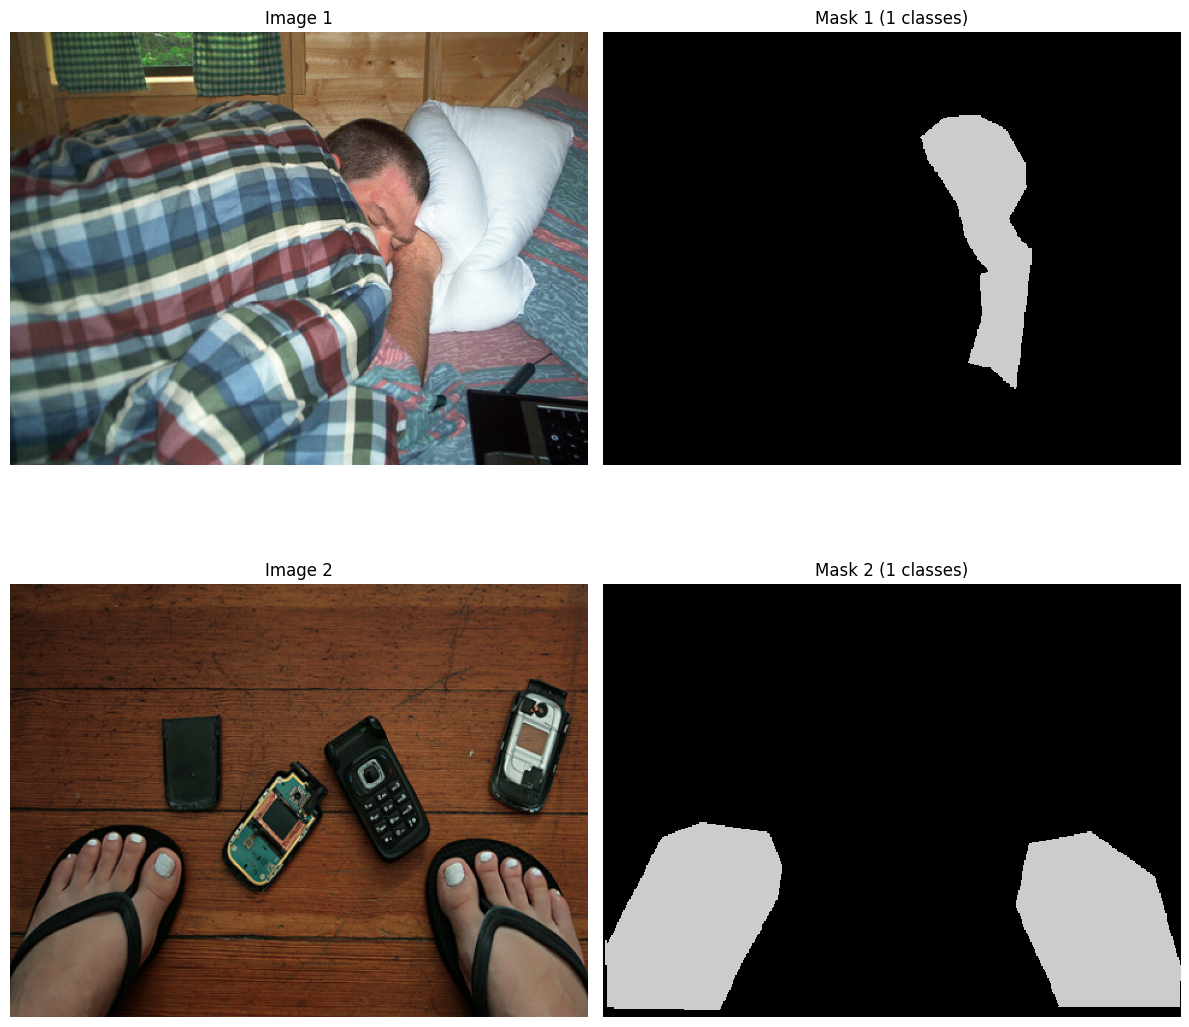


Batch info:
Images: torch.Size([8, 3, 360, 480])
Masks: torch.Size([8, 360, 480])
Classes: 2
  Sample 0: 1 classes present
  Sample 1: 1 classes present


In [5]:
import matplotlib.pyplot as plt
import numpy as np

sample_images, sample_masks = next(iter(train_loader))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i in range(min(2, len(sample_images))):
    img = sample_images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    
    axes[i*2].imshow(img)
    axes[i*2].set_title(f'Image {i+1}')
    axes[i*2].axis('off')
    
    mask = sample_masks[i].cpu().numpy()
    unique_classes = np.unique(mask)
    
    axes[i*2+1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=NUM_CLASSES-1, interpolation='nearest')
    axes[i*2+1].set_title(f'Mask {i+1} ({len(unique_classes)-1} classes)')
    axes[i*2+1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nBatch info:")
print(f"Images: {sample_images.shape}")
print(f"Masks: {sample_masks.shape}")
print(f"Classes: {NUM_CLASSES}")
for i in range(min(2, len(sample_images))):
    unique = np.unique(sample_masks[i].numpy())
    print(f"  Sample {i}: {len(unique)-1} classes present")


In [6]:
unet_model = UNetResNet50(num_classes=NUM_CLASSES, pretrained=True)

model = SegmentationModule(
    model=unet_model,
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    weight_decay=config['training']['weight_decay'],
    optimizer='adam'
)

print("UNet-ResNet50 model created for COCO semantic segmentation")


/home/tam2511/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tam2511/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


UNet-ResNet50 model created for COCO semantic segmentation


In [7]:
checkpoint_callback = ModelCheckpoint(
    dirpath=config['training']['checkpoint_dirpath'],
    filename=config['training']['checkpoint_filename'],
    save_top_k=config['training']['checkpoint_save_top_k'],
    monitor='val_iou',
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_iou',
    patience=config['training']['early_stopping_patience'],
    mode='max'
)

logger = TensorBoardLogger(
    save_dir=config['training']['log_dir'],
    name=config['training']['experiment_name']
)


In [8]:
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
    accelerator=config['hardware']['accelerator'],
    devices=config['hardware']['devices'],
    log_every_n_steps=config['training']['log_every_n_steps']
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [9]:
trainer.fit(model, train_loader, val_loader)


You are using a CUDA device ('NVIDIA L40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/tam2511/.local/lib/python3.8/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:652: Checkpoint directory /home/tam2511/mounts/0/arcadia/market/robotics/cv/ml/user_data/shad/seg/checkpoints_coco_unet_1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name       | Type                   | Params
------------------------------------------------------
0 | model      | UNetResNet50           | 109 M 
1 | train_loss | MeanMetric             | 0     
2 | val_loss   | MeanMetric             | 0     
3 | val_iou    | MulticlassJaccardIndex |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

[Epoch 0] Val Loss: 0.7021 | Val mIoU: 1.0000


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

[Epoch 8] Val Loss: 0.1530 | Val mIoU: 0.8589

[Epoch 8] Train Loss: 0.1230 | LR: 1.00e-04


Validation: |          | 0/? [00:00<?, ?it/s]

[Epoch 9] Val Loss: 0.1403 | Val mIoU: 0.8273

[Epoch 9] Train Loss: 0.1057 | LR: 9.94e-05


Validation: |          | 0/? [00:00<?, ?it/s]

[Epoch 10] Val Loss: 0.1494 | Val mIoU: 0.7660

[Epoch 10] Train Loss: 0.1016 | LR: 9.78e-05


In [1]:
print("\n" + "="*70)
print("="*70)

model.eval()
test_iou = model.val_iou

all_preds = []
all_masks = []

with torch.no_grad():
    for batch in test_loader:
        images, masks = batch
        images = images.to(model.device)
        masks = masks.to(model.device)
        
        outputs = model(images)
        preds = model.model.postprocess(outputs)
        
        all_preds.append(preds.cpu())
        all_masks.append(masks.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_masks = torch.cat(all_masks, dim=0)

test_iou.update(all_preds, all_masks)

final_test_iou = test_iou.compute()

print(f"\n✓ Test mIoU: {final_test_iou:.4f}")
print(f"\nPer-class IoU on test set:")
for i, class_name in enumerate(train_full_dataset.class_names):
    print(f"  {class_name:15s}: {final_test_iou_per_class[i]:.4f}")

test_iou.reset()


NameError: name 'model' is not defined

In [ ]:
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

sample_images, sample_masks = next(iter(val_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    outputs = model(sample_images)
    predictions = model.model.postprocess(outputs)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(min(2, len(sample_images))):
    img = sample_images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Input Image')
    axes[i, 0].axis('off')
    
    gt_mask = sample_masks[i].cpu().numpy()
    axes[i, 1].imshow(gt_mask, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f'Ground Truth ({gt_mask.sum()} person pixels)')
    axes[i, 1].axis('off')
    
    pred_mask = predictions[i].cpu().numpy()
    axes[i, 2].imshow(pred_mask, cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title(f'Prediction ({pred_mask.sum()} person pixels)')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
